# Project 2: Crop Health Monitoring System (Odisha Paddy Fields)
## Notebook 01: Baseline Simulation & Statistical Anomaly Detection Engine

**Author:** Gourgopal Mohapatra  
**Date:** June 2026  
**Objective:** Build a synthetic proof-of-concept for tracking Kharif Paddy phenology in Odisha. This notebook simulates a healthy historical baseline curve, injects high-frequency sensor noise, simulates catastrophic real-world stress events (drought/floods), and deploys a $2\sigma$ (Standard Deviation) anomaly detection engine.

In [1]:
# ==========================================
# STEP 1: IMPORT PRODUCTION LIBRARIES
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

print("🚀 Libraries imported successfully!")

🚀 Libraries imported successfully!


## Step 2: Simulating Kharif Season Paddy Phenology
The Kharif season in Odisha runs primarily from **June to November (~180 days)**.
We model the healthy paddy life cycle using a modified Sine Wave:
- **June-July (Days 1-50):** Transplanting phase (Low NDVI due to water logging in fields: 0.15 - 0.25).
- **August-September (Days 51-120):** Rapid vegetative growth (NDVI shoots up linearly to 0.75+).
- **October (Days 121-150):** Peak Heading/Flowering phase (NDVI saturates around 0.8).
- **November (Days 151-180):** Harvesting/Senescence (NDVI drops sharply as crop turns golden and is harvested).

In [2]:
# Set seed for reproducibility (Crucial to prevent random training slips)

np.random.seed(42)
days = np.arange(1, 181)

# 1. Generate Ideal Historical Baseline (Healthy Paddy Curve)
baseline_ndvi = 0.2 + 0.6 * np.sin(np.pi * (days - 10)  /  200)

# 2. Simulate Current Season with Sentinel-2 Sensor Noise
# Standard satellite data contains atmospheric/sensor scattering noise
sensor_noise = np.random.normal(0, 0.02, size = 180)
current_season_ndvi = baseline_ndvi + sensor_noise

print("✅ Healthy baseline and noisy current season data generated.")

✅ Healthy baseline and noisy current season data generated.


## Step 3: Injecting Real-World Crop Stress Events (The Ariane-5 Crash Test)
To test if our anomaly detection engine can catch hidden failures (unlike Project 1), we will intentionally inject two major agro-climatic anomalies:
1. **Mid-Season Drought / Pest Attack (August - Days 75 to 82):** Sudden drop of 0.18 in NDVI.
2. **Flash Floods / Submergence (October - Days 130 to 135):** Massive drop of 0.22 in NDVI.

In [3]:
# Clone the array to protect original noisy data
stressed_ndvi = current_season_ndvi.copy()

# Event 1: August Pest/Drought Shock
stressed_ndvi[74:82] -= 0.18

# Event 2: October Flash Flood Shock
stressed_ndvi[129:135] -= 0.22

print("🚨 Artificial stress events successfully injected into the time-series.")

🚨 Artificial stress events successfully injected into the time-series.


## Step 4: Deplaying the $2\sigma$ Anomaly Detection Engine
Industrial agritech models (like SatSure) flag anomalies when the current season's performance breaches statistical boundaries.
- **Threshold Equation:** $$Lower\ Threshold = \mu_{baseline} - (2 \times \sigma)$$
- **Logic:** Any pixel/field falling below $2\sigma$ for consecutive days triggers an early warning alert to insurance companies.

In [4]:
# Define historical standard deviation (Sigma) based on baseline variance
sigma = 0.04
lower_threshold = baseline_ndvi- (2 * sigma)

# Compute Anomaly Mask (Boolean Array: True where stress is detected)
anomaly_mask = stressed_ndvi < lower_threshold

# Find the exact days when anomaly occurred
anomaly_days = days[anomaly_mask]
print(f"🕵️ Anomaly Detector Active! Stress detected on {len(anomaly_days)} out of 180 days.")

🕵️ Anomaly Detector Active! Stress detected on 14 out of 180 days.


## Step 5: Advanced Visualization & Directory Export
We will generate a production-grade visualization plot and automatically export the figure and processed data into our structured `outputs/` and `data/` directories.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<>:22: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_640/3821388512.py:22: SyntaxWarning: invalid escape sequence '\p'
  plt.fill_between(days, lower_threshold, baseline_ndvi + (2 * sigma), color='#2ca02c', alpha=0.1, label='Normal Variance Bound ($\pm2\sigma$)')


📊 Visualization saved successfully in Google Drive at:
👉 /content/drive/My Drive/MISSION_RS_SDA/Crop_Health_Monitor_Odisha/outputs/figures/crop_health_anomaly_plot.png
💾 Tabular data exported successfully in Google Drive at:
👉 /content/drive/My Drive/MISSION_RS_SDA/Crop_Health_Monitor_Odisha/data/rasters_tabular/simulated_paddy_ndvi.csv


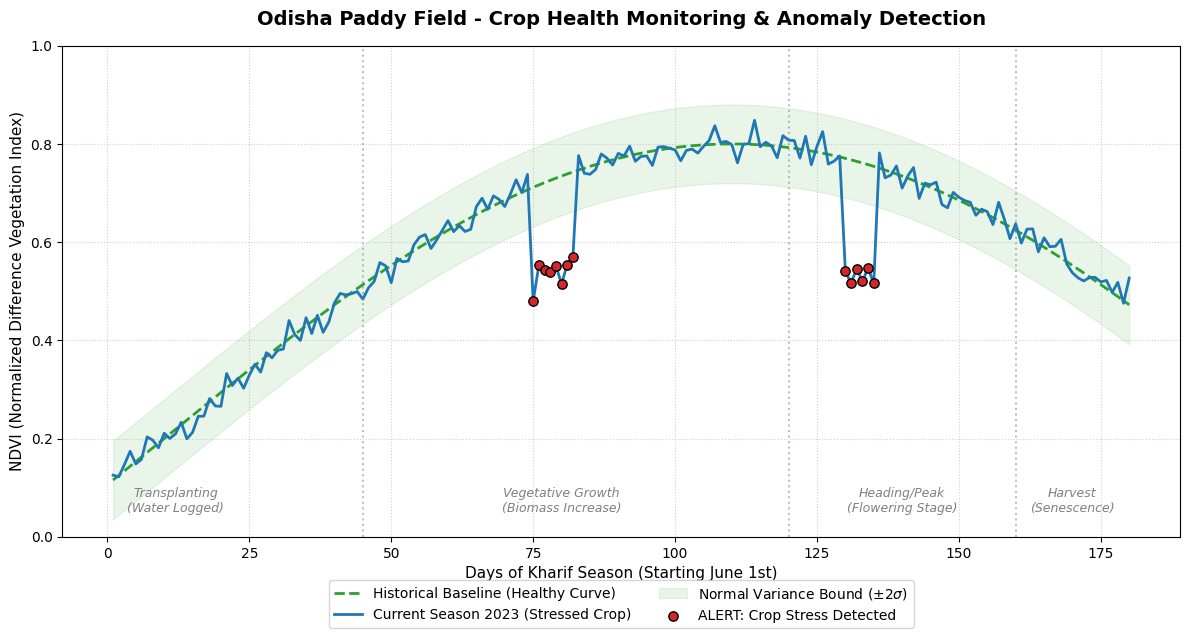

In [6]:
# =========================================================================
# STEP 5: FIXED PATHS FOR GOOGLE DRIVE EXPORT
# =========================================================================

import os

 # 1. Base path setting according to my exact Google Drive
base_drive_path = '/content/drive/My Drive/MISSION_RS_SDA/Crop_Health_Monitor_Odisha'

# Sub-folder paths define
figures_dir = os.path.join(base_drive_path, 'outputs/figures')
data_dir = os.path.join(base_drive_path, 'data/rasters_tabular')

# Automatically create outputs and data folders inside your Drive if they don't exist
os.makedirs(figures_dir, exist_ok = True)
os.makedirs(data_dir, exist_ok = True)

# 2. Build and formatting the plot (Same Dhasu Aesthetics)
plt.figure(figsize=(12, 6.5))
plt.plot(days, baseline_ndvi, label='Historical Baseline (Healthy Curve)', color='#2ca02c', linestyle='--', linewidth=2)
plt.plot(days, stressed_ndvi, label='Current Season 2023 (Stressed Crop)', color='#1f77b4', linewidth=2)
plt.fill_between(days, lower_threshold, baseline_ndvi + (2 * sigma), color='#2ca02c', alpha=0.1, label='Normal Variance Bound ($\pm2\sigma$)')
plt.scatter(days[anomaly_mask], stressed_ndvi[anomaly_mask], color='#d62728', label='ALERT: Crop Stress Detected', zorder=5, s=45, edgecolor='black')

plt.title('Odisha Paddy Field - Crop Health Monitoring & Anomaly Detection', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Days of Kharif Season (Starting June 1st)', fontsize=11)
plt.ylabel('NDVI (Normalized Difference Vegetation Index)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(0.0, 1.0)
plt.legend(loc='lower center', fontsize=10, bbox_to_anchor=(0.5, -0.2), ncol=2)

# Phenology annotations
stage_boundaries = [45, 120, 160]
for boundary in stage_boundaries:
    plt.axvline(x=boundary, color='gray', linestyle=':', alpha=0.5)

plt.text(12, 0.05, 'Transplanting\n(Water Logged)', fontsize=9, style='italic', color='gray', ha='center')
plt.text(80, 0.05, 'Vegetative Growth\n(Biomass Increase)', fontsize=9, style='italic', color='gray', ha='center')
plt.text(140, 0.05, 'Heading/Peak\n(Flowering Stage)', fontsize=9, style='italic', color='gray', ha='center')
plt.text(170, 0.05, 'Harvest\n(Senescence)', fontsize=9, style='italic', color='gray', ha='center')

plt.tight_layout()

# 3. Save Figure directly to your Google Drive 'outputs/figures' folder
fig_path = os.path.join(figures_dir, 'crop_health_anomaly_plot.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"📊 Visualization saved successfully in Google Drive at:\n👉 {fig_path}")

# 4. Save Simulated Tabular Data directly to 'data/rasters_tabular' folder
df_sim = pd.DataFrame({
    'Day': days,
    'Baseline_NDVI': baseline_ndvi,
    'Current_Season_NDVI': stressed_ndvi,
    'Lower_Threshold': lower_threshold,
    'Is_Anomaly': anomaly_mask.astype(int)
})
csv_path = os.path.join(data_dir, 'simulated_paddy_ndvi.csv')
df_sim.to_csv(csv_path, index=False)
print(f"💾 Tabular data exported successfully in Google Drive at:\n👉 {csv_path}")

plt.show()